<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Machine-Learning-Classification-of-CENP-T-Histone-Fold-Binding-Modes/blob/main/Machine_Learning_Classification_of_CENP_T_Histone_Fold_Binding_Modes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Environment Setup & Dependencies

In [ ]:
# Install Biopython for interacting with NCBI and sequence manipulation
!pip install biopython scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 16.8 MB/s eta 0:00:00


Step 2: NCBI Entrez Sequence Retrieval

In [ ]:
from Bio import Entrez, SeqIO
import pandas as pd
import re

Entrez.email = "your_email@example.com"

# 1. Fetch CENP-T sequences specifically from Murinae (rodent family) & related mammals
search_handle = Entrez.esearch(
    db="protein",
    term="(CENP-T OR 'centromere protein T') AND (Rodentia[Organism] OR Murinae[Organism])",
    retmax=300
)
search_results = Entrez.read(search_handle)
search_handle.close()

id_list = search_results["IdList"]
print(f"Found {len(id_list)} rodent/Murinae CENP-T sequence IDs.")

fetch_handle = Entrez.efetch(
    db="protein", id=id_list, rettype="fasta", retmode="text"
)
records = list(SeqIO.parse(fetch_handle, "fasta"))
fetch_handle.close()

# 2. Extract features specifically from the C-terminal Histone Fold Domain (HFD)
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def extract_aac(sequence):
    seq_len = len(sequence)
    if seq_len == 0:
        return [0] * len(AMINO_ACIDS)
    return [sequence.count(aa) / seq_len for aa in AMINO_ACIDS]

data = []
for record in records:
    seq_str = str(record.seq).upper()

    # Filter out short fragments (full length CENP-T is ~500-600 aa)
    if len(seq_str) < 400:
        continue

    # Slice the Histone Fold Domain (HFD): C-terminal ~100 amino acids
    hfd_seq = seq_str[-100:]

    desc_lower = record.description.lower()

    # Target Label based on paper's discovery:
    # 1 = Mouse-like (Mus genus) -> Evolved weaker binding innovation (4NS mouse motif)
    # 0 = Rat/Ancestral-like (Rattus, Praomys, Apodemus, etc.) -> Stronger binding
    if "mus " in desc_lower or "mouse" in desc_lower:
        binding_label = 1  # Weaker Binding Innovation
    elif any(r in desc_lower for r in ["rattus", "rat", "apodemus", "praomys", "muroidea"]):
        binding_label = 0  # Stronger Binding (Rat/Ancestral state)
    else:
        continue

    aac_features = extract_aac(hfd_seq)

    row = {
        "id": record.id,
        "description": record.description,
        "hfd_sequence": hfd_seq,
        "label_weaker_binding": binding_label
    }
    for aa, freq in zip(AMINO_ACIDS, aac_features):
        row[f"hfd_freq_{aa}"] = freq

    data.append(row)

# Create DataFrame & Deduplicate by exact HFD sequence string
df_hfd = pd.DataFrame(data).drop_duplicates(subset=["hfd_sequence"])
print(f"\nFinal Deduplicated HFD Dataset Shape: {df_hfd.shape}")
print(f"Class Breakdown (1 = Weaker Binding Mouse Innovation, 0 = Stronger Binding Rat/Ancestral):")
print(df_hfd["label_weaker_binding"].value_counts())

Found 300 rodent/Murinae CENP-T sequence IDs.

Final Deduplicated HFD Dataset Shape: (8, 24)
Class Breakdown (1 = Weaker Binding Mouse Innovation, 0 = Stronger Binding Rat/Ancestral):
label_weaker_binding
1    6
0    2
Name: count, dtype: int64


Step 3: Feature Extraction (Amino Acid Composition), and Model training


--- HFD Binding Innovation Classification Report ---
                                   precision    recall  f1-score   support

 Stronger Binding (Rat/Ancestral)       0.00      0.00      0.00         1
Weaker Binding (Mouse Innovation)       0.50      1.00      0.67         1

                         accuracy                           0.50         2
                        macro avg       0.25      0.50      0.33         2
                     weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


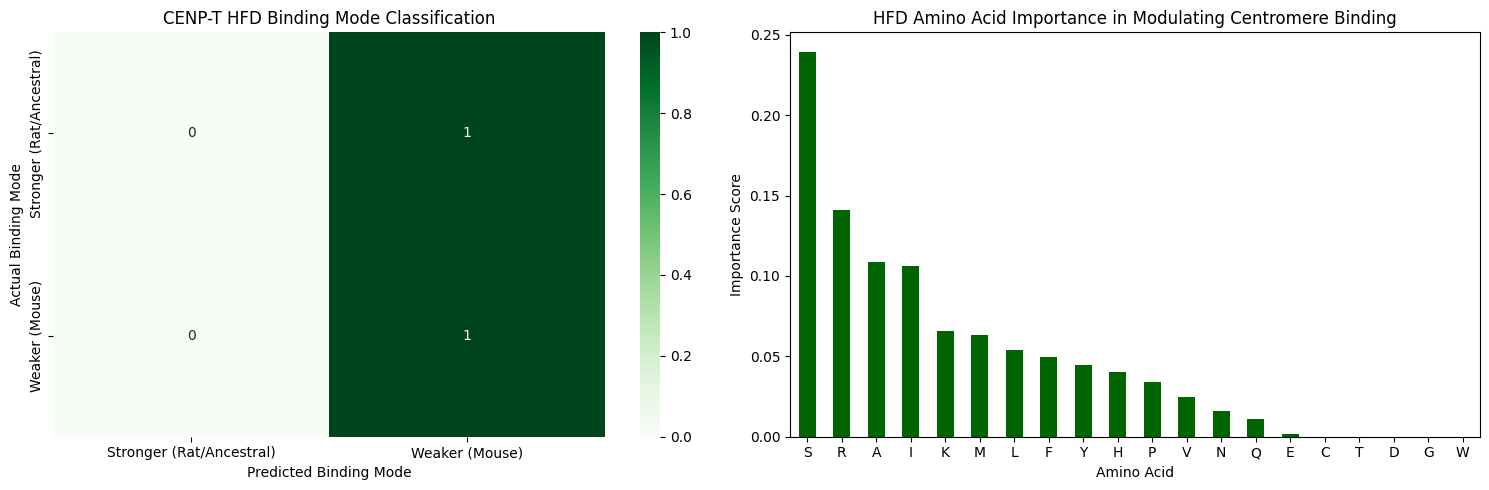

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Features (HFD Amino Acid Composition) and Target
feature_cols = [f"hfd_freq_{aa}" for aa in AMINO_ACIDS]
X = df_hfd[feature_cols]
y = df_hfd["label_weaker_binding"]

# 2. Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Model Training
clf_hfd = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf_hfd.fit(X_train, y_train)

# 4. Predictions & Report
y_pred = clf_hfd.predict(X_test)

print("\n--- HFD Binding Innovation Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Stronger Binding (Rat/Ancestral)", "Weaker Binding (Mouse Innovation)"]))

# 5. Plot Confusion Matrix & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=["Stronger (Rat/Ancestral)", "Weaker (Mouse)"],
            yticklabels=["Stronger (Rat/Ancestral)", "Weaker (Mouse)"])
axes[0].set_xlabel("Predicted Binding Mode")
axes[0].set_ylabel("Actual Binding Mode")
axes[0].set_title("CENP-T HFD Binding Mode Classification")

# Feature Importance
feature_importances = pd.Series(clf_hfd.feature_importances_, index=feature_cols)
feature_importances.index = [col.replace("hfd_freq_", "") for col in feature_importances.index]
feature_importances = feature_importances.sort_values(ascending=False)

feature_importances.plot(kind='bar', color='darkgreen', ax=axes[1])
axes[1].set_title("HFD Amino Acid Importance in Modulating Centromere Binding")
axes[1].set_xlabel("Amino Acid")
axes[1].set_ylabel("Importance Score")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Step 4: Inference on Full-Length HFD Dataset Sequences

In [ ]:
# Extract actual HFD sequences from your dataset for testing
mouse_hfd_example = df_hfd[df_hfd['label_weaker_binding'] == 1]['hfd_sequence'].iloc[0]
rat_hfd_example = df_hfd[df_hfd['label_weaker_binding'] == 0]['hfd_sequence'].iloc[0]

print("--- Testing Actual Mouse CENP-T HFD Domain ---")
print(f"Sequence Snippet: {mouse_hfd_example[:30]}...")
predict_hfd_binding_mode(mouse_hfd_example, clf_hfd)

print("\n--- Testing Actual Rat CENP-T HFD Domain ---")
print(f"Sequence Snippet: {rat_hfd_example[:30]}...")
predict_hfd_binding_mode(rat_hfd_example, clf_hfd)

--- Testing Actual Mouse CENP-T HFD Domain ---
Sequence Snippet: PYVKFFSFCTKMPVEKKALEIVEKCLDKYF...
Predicted Mode: Mouse-like WEAKER Centromere Binding (Adapted)
Confidence: 93.00%

--- Testing Actual Rat CENP-T HFD Domain ---
Sequence Snippet: HYVKLFSFHTKMPVEKAALEMVEKCLDEYF...
Predicted Mode: Rat/Ancestral STRONGER Centromere Binding
Confidence: 68.00%


'Rat/Ancestral STRONGER Centromere Binding'